## Impoer Libraries

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report, recall_score

import warnings
warnings.filterwarnings('ignore')

## Load Dataset

In [2]:
df = pd.read_csv('creditcard.csv')

## Inspect Data

In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [30]:
df.loc[:, ['Time', 'Amount']].describe()

,Time,Amount
count,284807.000000,284807.000000
mean,94813.859575,88.349619
std,47488.145955,250.120109
min,0.000000,0.000000
25%,54201.500000,5.600000
50%,84692.000000,22.000000
75%,139320.500000,77.165000
max,172792.000000,25691.160000


In [6]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [11]:
df.shape

(284807, 31)

In [7]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [16]:
df['Class'].map({0: 'Normal', 1: 'Fraud'}).value_counts()

Class
Normal    284315
Fraud        492
Name: count, dtype: int64

## Visualization

Text(0.5, 1.0, 'The Fraud Transactions are 0.17% of the dataset')

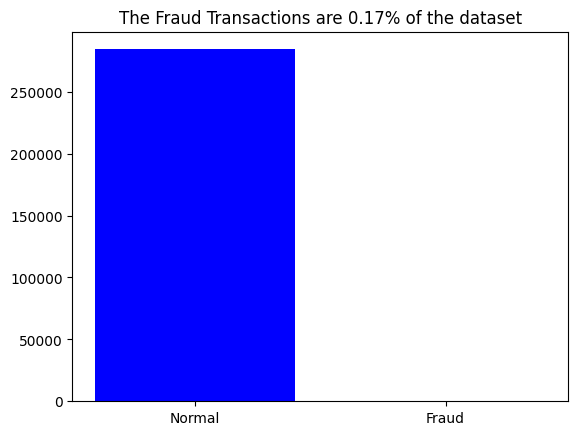

In [23]:
Normal_len = len(df[df["Class"]==0])
Fraud_len = len(df[df["Class"]==1])

plt.bar([0 ,1], [Normal_len, Fraud_len], color=['b' ,'r'])
plt.xticks([0, 1], ["Normal", "Fraud"])

t = round((Fraud_len/len(df) * 100),2)
plt.title(f"The Fraud Transactions are {t}% of the dataset")

<Axes: >

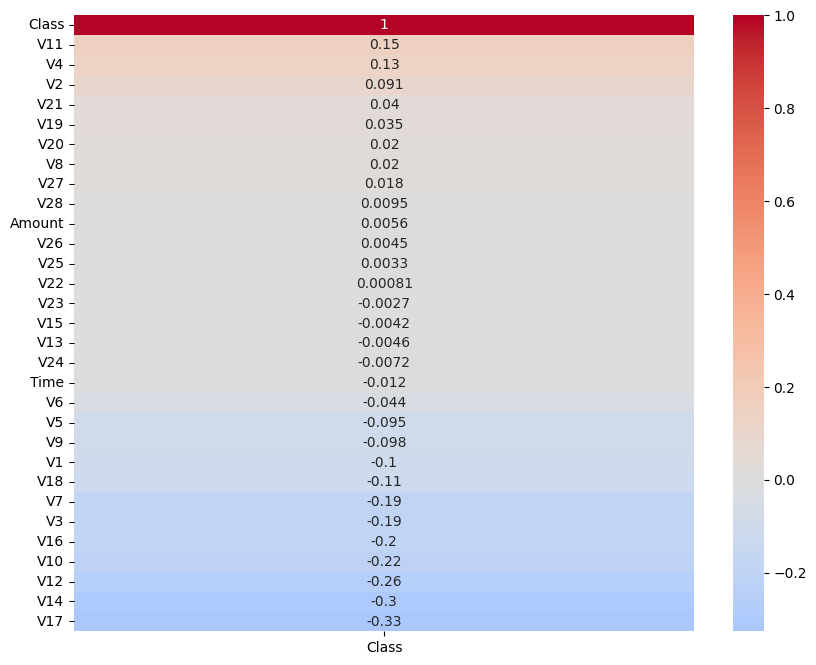

In [29]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr()[['Class']].sort_values('Class', ascending=False), 
            annot=True, cmap='coolwarm', center=0)

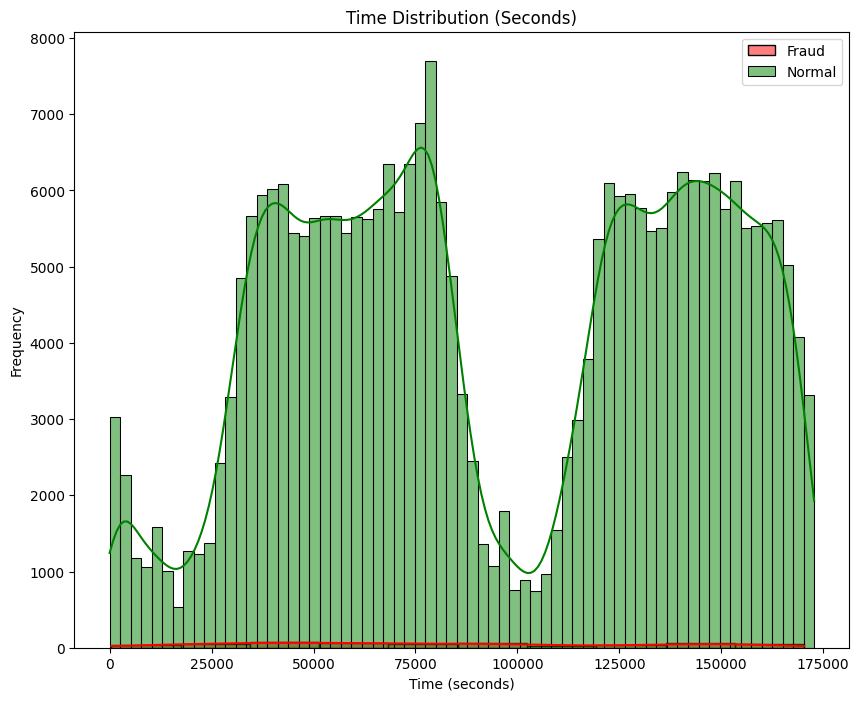

In [37]:
plt.figure(figsize=(10, 8))

plt.title('Time Distribution (Seconds)')

# Fraud
sns.histplot(df[df['Class'] == 1]['Time'], color='red', kde=True, label='Fraud')

# Normal
sns.histplot(df[df['Class'] == 0]['Time'], color='green', kde=True, label='Normal')

plt.xlabel('Time (seconds)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

## ML models

In [47]:
X = df.drop('Class',axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

In [48]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

best_model = None
best_recall = 0

In [49]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print(f"\n=== {name} ===")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("Classification Report:")
    print(classification_report(y_test, y_pred, digits=3))
    
    recall = recall_score(y_test, y_pred)
    if recall > best_recall:
        best_model = name
        best_recall = recall


=== Logistic Regression ===
Confusion Matrix:
[[85279    18]
 [   46   100]]
Classification Report:
              precision    recall  f1-score   support

           0      0.999     1.000     1.000     85297
           1      0.847     0.685     0.758       146

    accuracy                          0.999     85443
   macro avg      0.923     0.842     0.879     85443
weighted avg      0.999     0.999     0.999     85443


=== Decision Tree ===
Confusion Matrix:
[[85257    40]
 [   26   120]]
Classification Report:
              precision    recall  f1-score   support

           0      1.000     1.000     1.000     85297
           1      0.750     0.822     0.784       146

    accuracy                          0.999     85443
   macro avg      0.875     0.911     0.892     85443
weighted avg      0.999     0.999     0.999     85443


=== Random Forest ===
Confusion Matrix:
[[85287    10]
 [   26   120]]
Classification Report:
              precision    recall  f1-score   support



In [50]:
print(f"\nBest model based on recall: {best_model} with recall = {best_recall:.3f}")


Best model based on recall: Decision Tree with recall = 0.822
